<a href="https://colab.research.google.com/github/rhodes-byu/cs-stat-180/blob/main/labs/05-cereal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 180 Lab 5: Cereal Data

## Introduction:


Everyone loves cereal. But have you ever thought deeply about your cereal? Well now is your chance to take a data driven view of your breakfast.

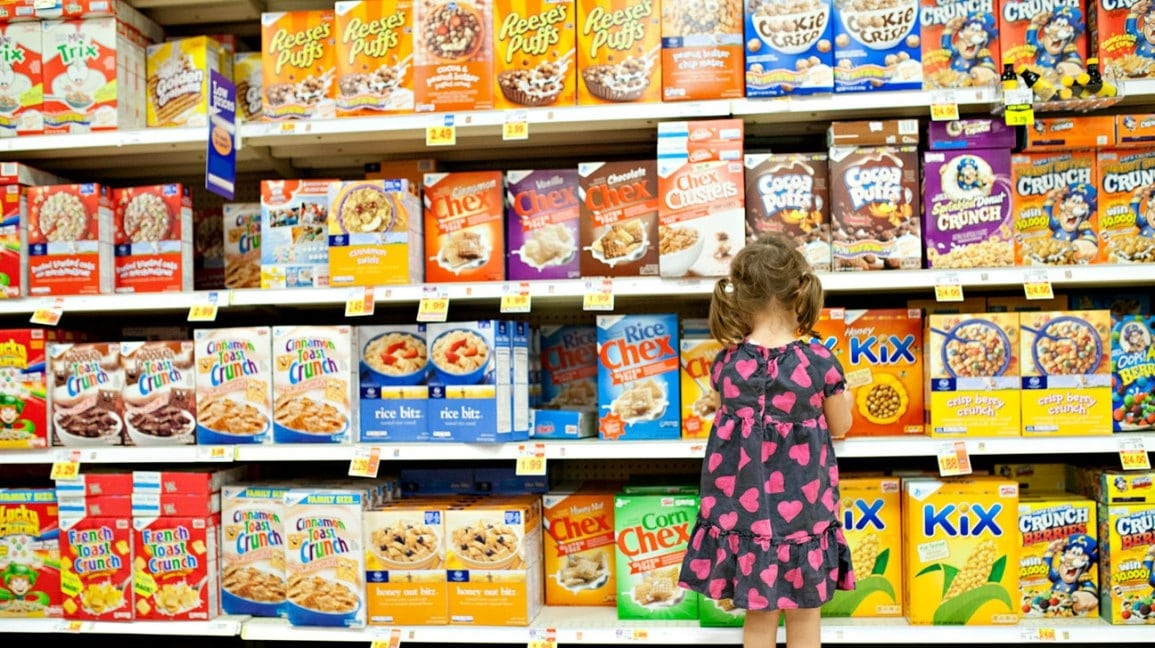


### Getting Started:
Download the data from github. Run the code below to download the data that you'll be using in this lab.

You may use pandas, numpy, matplotlib and/or seaborn for these excercises.

You can use/read their respective documentation in the links below (only if you need too, it's not required for the lab):

*   Seaborn [Documentation]("https://seaborn.pydata.org/tutorial.html")
*   Matplotlib [Documentation]("https://matplotlib.org/stable/api/index.html")
*   Numpy [Documentation]("https://numpy.org/doc/1.23/user/index.html#user")
*   Pandas [Documentation]("https://pandas.pydata.org/docs/user_guide/index.html#user-guide")







In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
cereal = pd.read_csv('https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cereal.csv')
cereal

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,G,C,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,Trix,G,C,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,Wheat Chex,R,C,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,Wheaties,G,C,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


## Exercise 1: Protein Powder
Carbs, fats and proteins are the three primary macro nutrients. Create a figure plotting the distribution of each of these macro nutrients together (i.e., three distributions on a single plot). Make sure to provide a legend.

Text(0, 0.5, 'Frequency')

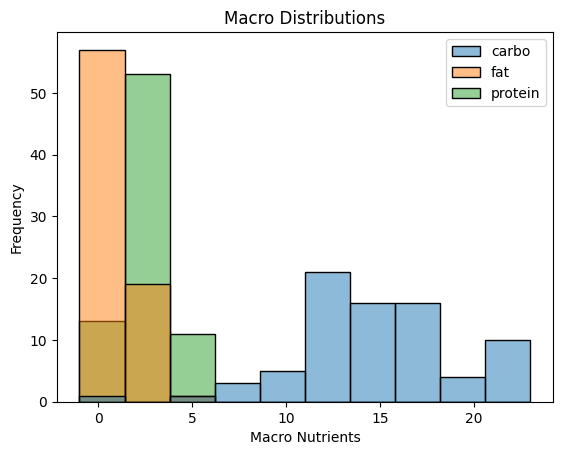

In [2]:
# Enter all of your code for exercise 1 here. Feel free to add more cells if you need to:
filt_macros = cereal[['carbo', 'fat', 'protein']]
filt_macros

sns.histplot(data=filt_macros, bins=10)
plt.title("Macro Distributions")
plt.xlabel("Macro Nutrients")
plt.ylabel("Frequency")


## Exercise 2: Sugar Daddy
Get a list of the top 5 most sugary cereals and the 5 least sugary cereals.

In [3]:
# Enter all of your code for exercise 2 here. Feel free to add more cells if you need to:
# Make a copy to safely modify it
sugars = cereal[['name', 'sugars']].copy()

list_of_names = []

for i in range(5):
    sweetest_cereal_index = sugars['sugars'].idxmax()
    cereal_name = sugars.loc[sweetest_cereal_index, 'name']
    list_of_names.append(cereal_name)
    sugars.drop(sweetest_cereal_index, inplace=True)
print(list_of_names)

['Golden Crisp', 'Smacks', 'Apple Jacks', 'Post Nat. Raisin Bran', 'Total Raisin Bran']


## Exercise 3: Cereal Killer
Get a list of the top 5 highest rated and lowest rated cereals.

In [4]:
# Enter all of your code for exercise 3 here. Feel free to add more cells if you need to:
sugars = cereal[['name', 'rating']].copy()

high_ranking_names = []
for i in range(5):
    sweetest_cereal_index = sugars['rating'].idxmax()
    cereal_name = sugars.loc[sweetest_cereal_index, 'name']
    high_ranking_names.append(cereal_name)
    sugars.drop(sweetest_cereal_index, inplace=True)

low_ranking_names = []
for i in range(5):
    sweetest_cereal_index = sugars['rating'].idxmin()
    cereal_name = sugars.loc[sweetest_cereal_index, 'name']
    low_ranking_names.append(cereal_name)
    sugars.drop(sweetest_cereal_index, inplace=True)

print(f"Top 5 highest rated cereals: {high_ranking_names}")
print(f"Top 5 lowest rated cereals: {low_ranking_names}")

Top 5 highest rated cereals: ['All-Bran with Extra Fiber', "Shredded Wheat 'n'Bran", 'Shredded Wheat spoon size', '100% Bran', 'Shredded Wheat']
Top 5 lowest rated cereals: ["Cap'n'Crunch", 'Cinnamon Toast Crunch', 'Honey Graham Ohs', 'Count Chocula', 'Cocoa Puffs']


## Exercise 4: America
Quantify the relationship between sugar and ratings.

Make a plot to visualize this relationship. Superimpose a best fit line (with seaborn) to describe the relationship. It may be helpful to look at the [seaborn regplot documentation]("https://seaborn.pydata.org/generated/seaborn.regplot.html").

Text(0, 0.5, 'Rating')

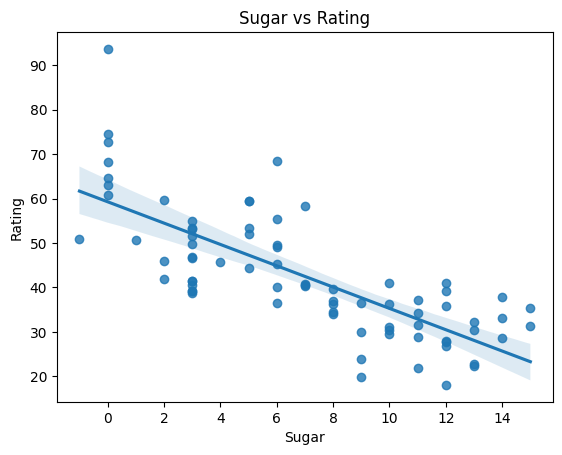

In [5]:
# Make the plot for the data visualization and line of best fit here:
sns.regplot(data=cereal, x='sugars', y='rating')
plt.title("Sugar vs Rating")
plt.xlabel("Sugar")
plt.ylabel("Rating")


Calculate a correlation statistic describing the relationship between sugar and ratings  (i.e., r or r squared).

In [6]:
# Calculate the statistic using this cell:
correlation = cereal['sugars'].corr(cereal['rating'])
print(f'Correlation: {correlation}')


Correlation: -0.7596746584301076


Write a statement in plain English interpreting this statistic.

There's a strong negative correlation between the amount of sugar in cereal and its ratings. It is noticeable that as amount of sugar increases, ratings decrease significantly, with a negative correlation of .75

## Exercise 5: America Part 2
Make five plots comparing the relationships of carbo, sugars, calories, protein, and fat with rating.

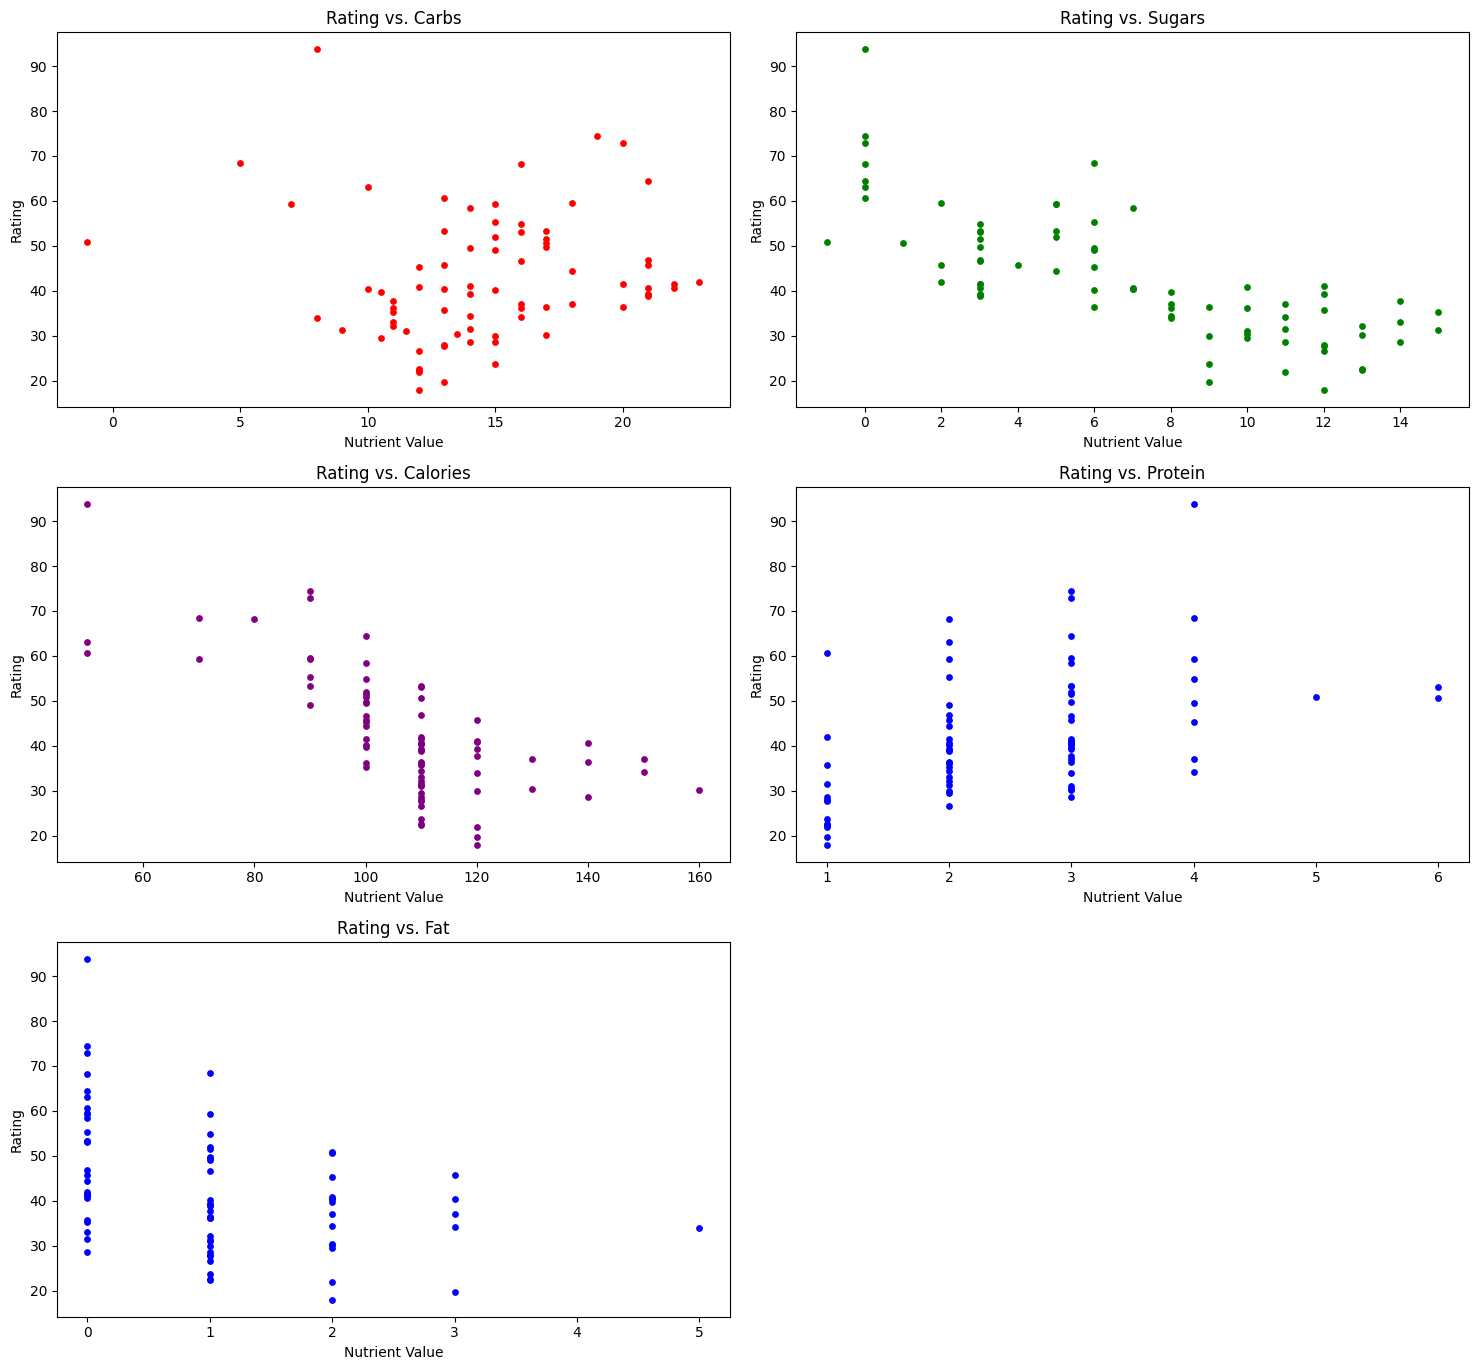

In [7]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

# Top-left plot
axs[0, 0].scatter(cereal['carbo'], cereal['rating'], color='red', s=15)
axs[0, 0].set_title('Rating vs. Carbs')

# Top-right plot
axs[0, 1].scatter(cereal['sugars'], cereal['rating'], color='green', s=15)
axs[0, 1].set_title('Rating vs. Sugars')

# Bottom-left plot
axs[1, 0].scatter(cereal['calories'], cereal['rating'], color='purple', s=15)
axs[1, 0].set_title('Rating vs. Calories')

# Bottom-right plot
axs[1, 1].scatter(cereal['protein'], cereal['rating'], color='blue', s=15)
axs[1, 1].set_title('Rating vs. Protein')

# Bottom plot
axs[2, 0].scatter(cereal['fat'], cereal['rating'], color='blue', s=15)
axs[2, 0].set_title('Rating vs. Fat')

for ax in axs.flat:
    ax.set_xlabel('Nutrient Value', fontsize=10)
    ax.set_ylabel('Rating', fontsize=10)

# Fit plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

axs.flat[-1].axis('off')

# Show the final combined plot
plt.show()


# Used Gemini to figure out how to not overlap the plots as I was playing around and learning how to label them and put titles on them

Of the variables carbo, sugars, calories, protein, and fat, which has the strongest relationship with rating? Justify your answer.

In [8]:
correlation = cereal['sugars'].corr(cereal['rating'])
print(f'Sugars: {correlation}')

correlation = cereal['carbo'].corr(cereal['rating'])
print(f'Carbs: {correlation}')

correlation = cereal['protein'].corr(cereal['rating'])
print(f'Protein: {correlation}')

correlation = cereal['fat'].corr(cereal['rating'])
print(f'Fat: {correlation}')

correlation = cereal['calories'].corr(cereal['rating'])
print(f'Calories: {correlation}')

Sugars: -0.7596746584301076
Carbs: 0.05205466123376461
Protein: 0.4706184645492595
Fat: -0.40928366014781
Calories: -0.6893760311652586


From the code I inserted above, the correlation which is the highest (positive) is that of protein vs rating, with a positive correlation of .47. This indicates that as protein amount increases, so do ratings.

However, the stronges correlation (absolute value), is still that of sugars vs ratings. Which, as previously inferred, has a .75 correlation. So, as sugar amount increases, ratings decrease.

## Exercise 6: Preparing for Mt. Everest
Do the same as you did with exercise 5, but instead compare carbo, sugars, protein, and fat with calories.

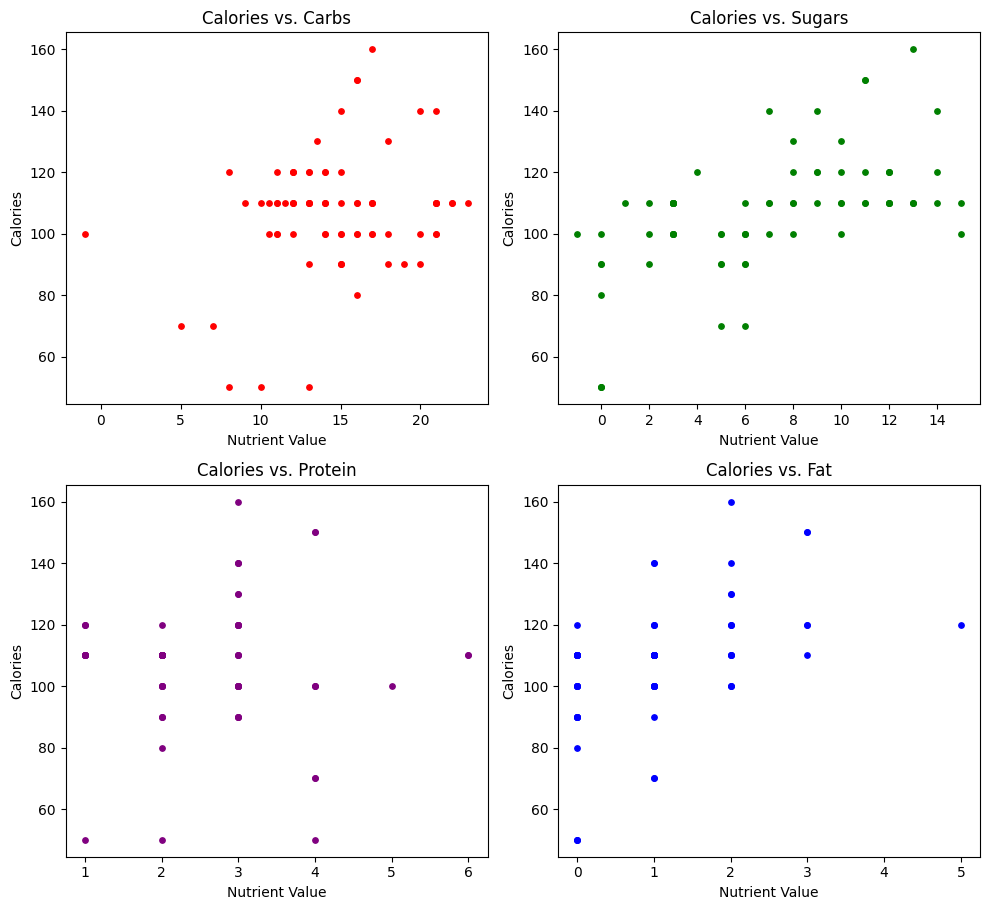

In [9]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# Top-left plot
axs[0, 0].scatter(cereal['carbo'], cereal['calories'], color='red', s=15)
axs[0, 0].set_title('Calories vs. Carbs')

# Top-right plot
axs[0, 1].scatter(cereal['sugars'], cereal['calories'], color='green', s=15)
axs[0, 1].set_title('Calories vs. Sugars')

# Bottom-left plot
axs[1, 0].scatter(cereal['protein'], cereal['calories'], color='purple', s=15)
axs[1, 0].set_title('Calories vs. Protein')

# Bottom-right plot
axs[1, 1].scatter(cereal['fat'], cereal['calories'], color='blue', s=15)
axs[1, 1].set_title('Calories vs. Fat')

for ax in axs.flat:
    ax.set_xlabel('Nutrient Value', fontsize=10)
    ax.set_ylabel('Calories', fontsize=10)

# Fit plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the final combined plot
plt.show()

# Same as above:
# Used Gemini to figure out how to not overlap the plots as I was playing around and learning how to label them and put titles on them

Of the variables carbo, sugars, protein, and fat, which has the strongest relationship with calories? Justify your answer.

In [10]:
correlation = cereal['carbo'].corr(cereal['calories'])
print(f'Carbs: {correlation}')

correlation = cereal['protein'].corr(cereal['calories'])
print(f'Protein: {correlation}')

correlation = cereal['sugars'].corr(cereal['calories'])
print(f'Sugars: {correlation}')

correlation = cereal['fat'].corr(cereal['calories'])
print(f'Fat: {correlation}')

Carbs: 0.25068091469892756
Protein: 0.019066068232357035
Sugars: 0.5623402898034883
Fat: 0.4986098143003877


The strongest correlation is between sugars and calories, with a correlation of .56. So, as sugar amount increase. However, the .56 correlation suggests that it's only moderate.

## Exercise 7: It’s Hot and It's Cold
The type column has two values: H='hot' and C='cold'. What is the average rating of each type?

In [11]:
# Write your code to get the average rating by type of cereal below:
cereal_temp = cereal.groupby('type')['rating'].mean()
print("Average Rating for each cereal type: Cold/Hot")
print(cereal_temp)

Average Rating for each cereal type: Cold/Hot
type
C    42.095218
H    56.737708
Name: rating, dtype: float64


## Exercise 8: Captain Crunch the Numbers
Provide one additional insight from this dataset that you found interesting. Create at least one figure and explain why the figure was interesting to you.

Text(0, 0.5, 'Rating')

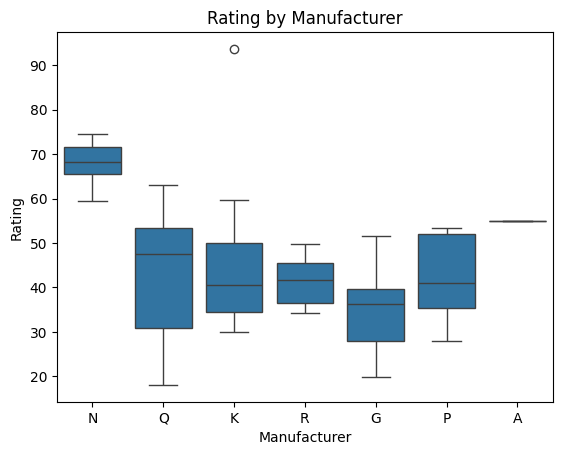

In [13]:
# Create the extra plot below:
manufacturers = pd.DataFrame(cereal.groupby('mfr')['rating'])

sns.boxplot(data=cereal, x='mfr', y='rating')
plt.title("Rating by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Rating")

# print(cereal.groupby('mfr')['rating'].mean().sort_values(ascending=True))

The most successful cereal manufacturer, based-off ratings, is Nabisco. Not only does it have the higest mean averages, but the IQR is quite low, meaning that the ratings were consistent.

However, the manufacturer with the higest rating overall was Kellogs, although that rating was an outlier, as it actually ranks third in mean ratings.

Quaker Oats is the manufacturer with the widest variation in ratings.

***Note that I had to look up the codes for these cereals, as the data set only contains single-letter codes for these***